# Global AI & Data Jobs — EDA + PyCaret Regression Pipeline (with MLflow)

**Assignment:** IT3385 — Task 1 (Exploratory Data Analysis) and Task 2 (PyCaret ML Pipeline with MLflow logging & model registration)

**Dataset:** `Global AI & Data Jobs Salary Dataset` (Kaggle), loaded from a local portable environment.

**Target variable for modelling:** `salary_usd` (annual base salary in USD).
> *Assumption:* the assignment brief does not name a specific target column. Since this is a salary dataset and `salary_usd` is the natural continuous outcome of interest for HR/compensation analytics, this notebook treats it as the regression target. If a different target (e.g. `bonus_usd`, `layoff_risk`, `employee_satisfaction`) is required, only the `setup()` call in Task 2 needs to change.

**Environment notes**
- Run this notebook inside your portable env: `C:\Users\crypt\Downloads\IT3385\IT3385_Env_class`
- Required packages: `pandas`, `numpy`, `matplotlib`, `seaborn`, `pycaret[full]`, `mlflow`
- If not already installed, run in a cell: `!pip install pycaret mlflow` (do this once, then restart the kernel — PyCaret pins many dependency versions).


In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

In [51]:
# -------------------------------------------------------------------
# Portable project paths
# -------------------------------------------------------------------
# This notebook may be started from the project root, notebooks folder,
# or the Long Chen notebook folder itself.
# Locate the Cookiecutter project root automatically so the notebook
# continues to work after the project is moved to another PC.

cur_dir = Path.cwd().resolve()
print("Current working directory:", cur_dir)


def locate_project_root(start_dir: Path) -> Path:
    search_roots = [start_dir, *start_dir.parents]

    for base in search_roots:
        # Identify the Cookiecutter project root
        if (
            (base / "pyproject.toml").exists()
            and (base / "data").is_dir()
            and (base / "notebooks").is_dir()
            and (base / "src").is_dir()
        ):
            return base

    raise FileNotFoundError(
        "Could not locate the IT3385_Team5_Assignment project root. "
        "Keep this notebook inside the ML project structure."
    )


PROJECT_ROOT = locate_project_root(cur_dir)

# Dataset location in the new Cookiecutter structure
DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "Long Chen"
    / "global_ai_jobs.csv"
)

# Flask application location in the new Cookiecutter structure
APP_DIR = (
    PROJECT_ROOT
    / "src"
    / "team5_app"
    / "Long Chen"
    / "salary_predictor_app"
)

FINAL_MODEL_PATH = APP_DIR / "employee_salary_final_model"

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_FILE)
print("Application directory:", APP_DIR)
print("Final model target:", FINAL_MODEL_PATH)
print("Pandas version:", pd.__version__)

Current working directory: C:\IT3385\IT3385_Env_class\notebooks\IT3385_Team5_Assignment\notebooks
Project root: C:\IT3385\IT3385_Env_class\notebooks\IT3385_Team5_Assignment
Dataset: C:\IT3385\IT3385_Env_class\notebooks\IT3385_Team5_Assignment\data\raw\Long Chen\global_ai_jobs.csv
Application directory: C:\IT3385\IT3385_Env_class\notebooks\IT3385_Team5_Assignment\src\team5_app\Long Chen\salary_predictor_app
Final model target: C:\IT3385\IT3385_Env_class\notebooks\IT3385_Team5_Assignment\src\team5_app\Long Chen\salary_predictor_app\employee_salary_final_model
Pandas version: 2.1.4


In [6]:
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Dataset was not found at: {DATA_FILE}\n"
        'Expected location: Long Chen/data/global_ai_jobs.csv'
    )

df = pd.read_csv(DATA_FILE)
print("Shape:", df.shape)
df.head()

Shape: (90000, 35)


,id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,company_size,interview_rounds,year,work_mode,weekly_hours,company_rating,job_openings,hiring_difficulty_score,layoff_risk,ai_adoption_score,company_funding_billion,economic_index,ai_maturity_years,offer_acceptance_rate,tax_rate_percent,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,1,UAE,Machine Learning Engineer,Reinforcement Learning,Entry,0,66465,5395,Master,Automotive,Small,7,2020,Remote,44.7,3.67,10,52.765351,0.404,91,3.30,78.65,13,60.58,20.8,27,12,76,57,65,73,15,55,1.23,76
1,2,USA,AI Engineer,LLM,Entry,1,75507,11713,Bootcamp,Retail,Small,3,2021,Onsite,48.9,4.26,27,53.114580,0.387,71,4.39,62.14,13,75.80,28.4,27,54,29,69,60,51,15,58,0.87,67
2,3,Brazil,Research Scientist,Analytics,Entry,0,41660,5268,PhD,Healthcare,Large,3,2020,Remote,46.8,4.78,10,76.395263,0.415,69,5.04,87.47,8,62.95,12.2,13,12,49,70,59,68,37,13,2.13,61
3,4,India,Software Engineer AI,Computer Vision,Senior,6,43268,7975,Diploma,Tech,Large,2,2026,Onsite,52.2,4.34,23,59.340199,0.115,74,4.38,86.84,7,77.45,35.1,30,80,47,79,65,55,46,74,1.49,56
4,5,Germany,Machine Learning Engineer,Computer Vision,Entry,0,69119,4758,Master,Retail,Medium,2,2021,Hybrid,46.7,4.49,17,72.301128,0.311,68,6.67,79.84,7,89.86,36.1,24,82,47,64,52,69,17,21,0.87,72


---
# Task 1 — Exploratory Data Analysis (EDA)

We inspect structure, quality, distributions and relationships in the dataset before modelling.


## 1.1 Structural overview
Check data types, non-null counts and get a first statistical summary.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       90000 non-null  int64  
 1   country                  90000 non-null  object 
 2   job_role                 90000 non-null  object 
 3   ai_specialization        90000 non-null  object 
 4   experience_level         90000 non-null  object 
 5   experience_years         90000 non-null  int64  
 6   salary_usd               90000 non-null  int64  
 7   bonus_usd                90000 non-null  int64  
 8   education_required       90000 non-null  object 
 9   industry                 90000 non-null  object 
 10  company_size             90000 non-null  object 
 11  interview_rounds         90000 non-null  int64  
 12  year                     90000 non-null  int64  
 13  work_mode                90000 non-null  object 
 14  weekly_hours          

In [8]:
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
id,90000.0,45000.500000,25980.906451,1.0,22500.750000,45000.500000,67500.250000,90000.000
experience_years,90000.0,7.028133,5.889327,0.0,2.000000,6.000000,12.000000,19.000
salary_usd,90000.0,96546.249222,43935.479553,28000.0,64676.750000,87544.000000,123906.000000,300622.000
bonus_usd,90000.0,13028.418722,7886.738085,1404.0,7104.750000,11279.000000,16997.250000,57681.000
interview_rounds,90000.0,4.495689,1.704553,2.0,3.000000,4.000000,6.000000,7.000
year,90000.0,2023.003200,2.002624,2020.0,2021.000000,2023.000000,2025.000000,2026.000
weekly_hours,90000.0,45.476268,5.475497,36.0,40.700000,45.500000,50.200000,55.000
company_rating,90000.0,3.998004,0.461914,3.2,3.600000,4.000000,4.400000,4.800
job_openings,90000.0,17.521867,7.848576,1.0,12.000000,17.000000,23.000000,50.000
hiring_difficulty_score,90000.0,55.028604,17.901451,0.0,42.881134,55.066089,67.118119,100.000


In [9]:
df.describe(include="object").T

,count,unique,top,freq
country,90000,12,Canada,7602
job_role,90000,8,NLP Engineer,11412
ai_specialization,90000,8,Computer Vision,11487
experience_level,90000,4,Senior,22680
education_required,90000,5,Bootcamp,18148
industry,90000,10,Gaming,9190
company_size,90000,5,Medium,18328
work_mode,90000,3,Onsite,30233


## 1.2 Missing values
Identify columns with missing data and their proportion, to decide on an imputation/cleaning strategy before feeding data to PyCaret (PyCaret can also handle missing values internally via `setup()`, but it's good practice to understand them first).

In [10]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_pct


## 1.3 Duplicate records

In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 1.4 Column typing
Separate numeric and categorical columns for targeted analysis.

In [12]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

# id is an identifier, not a feature for distribution analysis
if "id" in numeric_cols:
    numeric_cols.remove("id")

print("Numeric columns ({}):".format(len(numeric_cols)), numeric_cols)
print("\nCategorical columns ({}):".format(len(categorical_cols)), categorical_cols)


Numeric columns (26): ['experience_years', 'salary_usd', 'bonus_usd', 'interview_rounds', 'year', 'weekly_hours', 'company_rating', 'job_openings', 'hiring_difficulty_score', 'layoff_risk', 'ai_adoption_score', 'company_funding_billion', 'economic_index', 'ai_maturity_years', 'offer_acceptance_rate', 'tax_rate_percent', 'vacation_days', 'skill_demand_score', 'automation_risk', 'job_security_score', 'career_growth_score', 'work_life_balance_score', 'promotion_speed', 'salary_percentile', 'cost_of_living_index', 'employee_satisfaction']

Categorical columns (8): ['country', 'job_role', 'ai_specialization', 'experience_level', 'education_required', 'industry', 'company_size', 'work_mode']


## 1.5 Univariate analysis — numeric distributions
Histograms with KDE for every numeric feature to check skewness, spread and possible outliers.

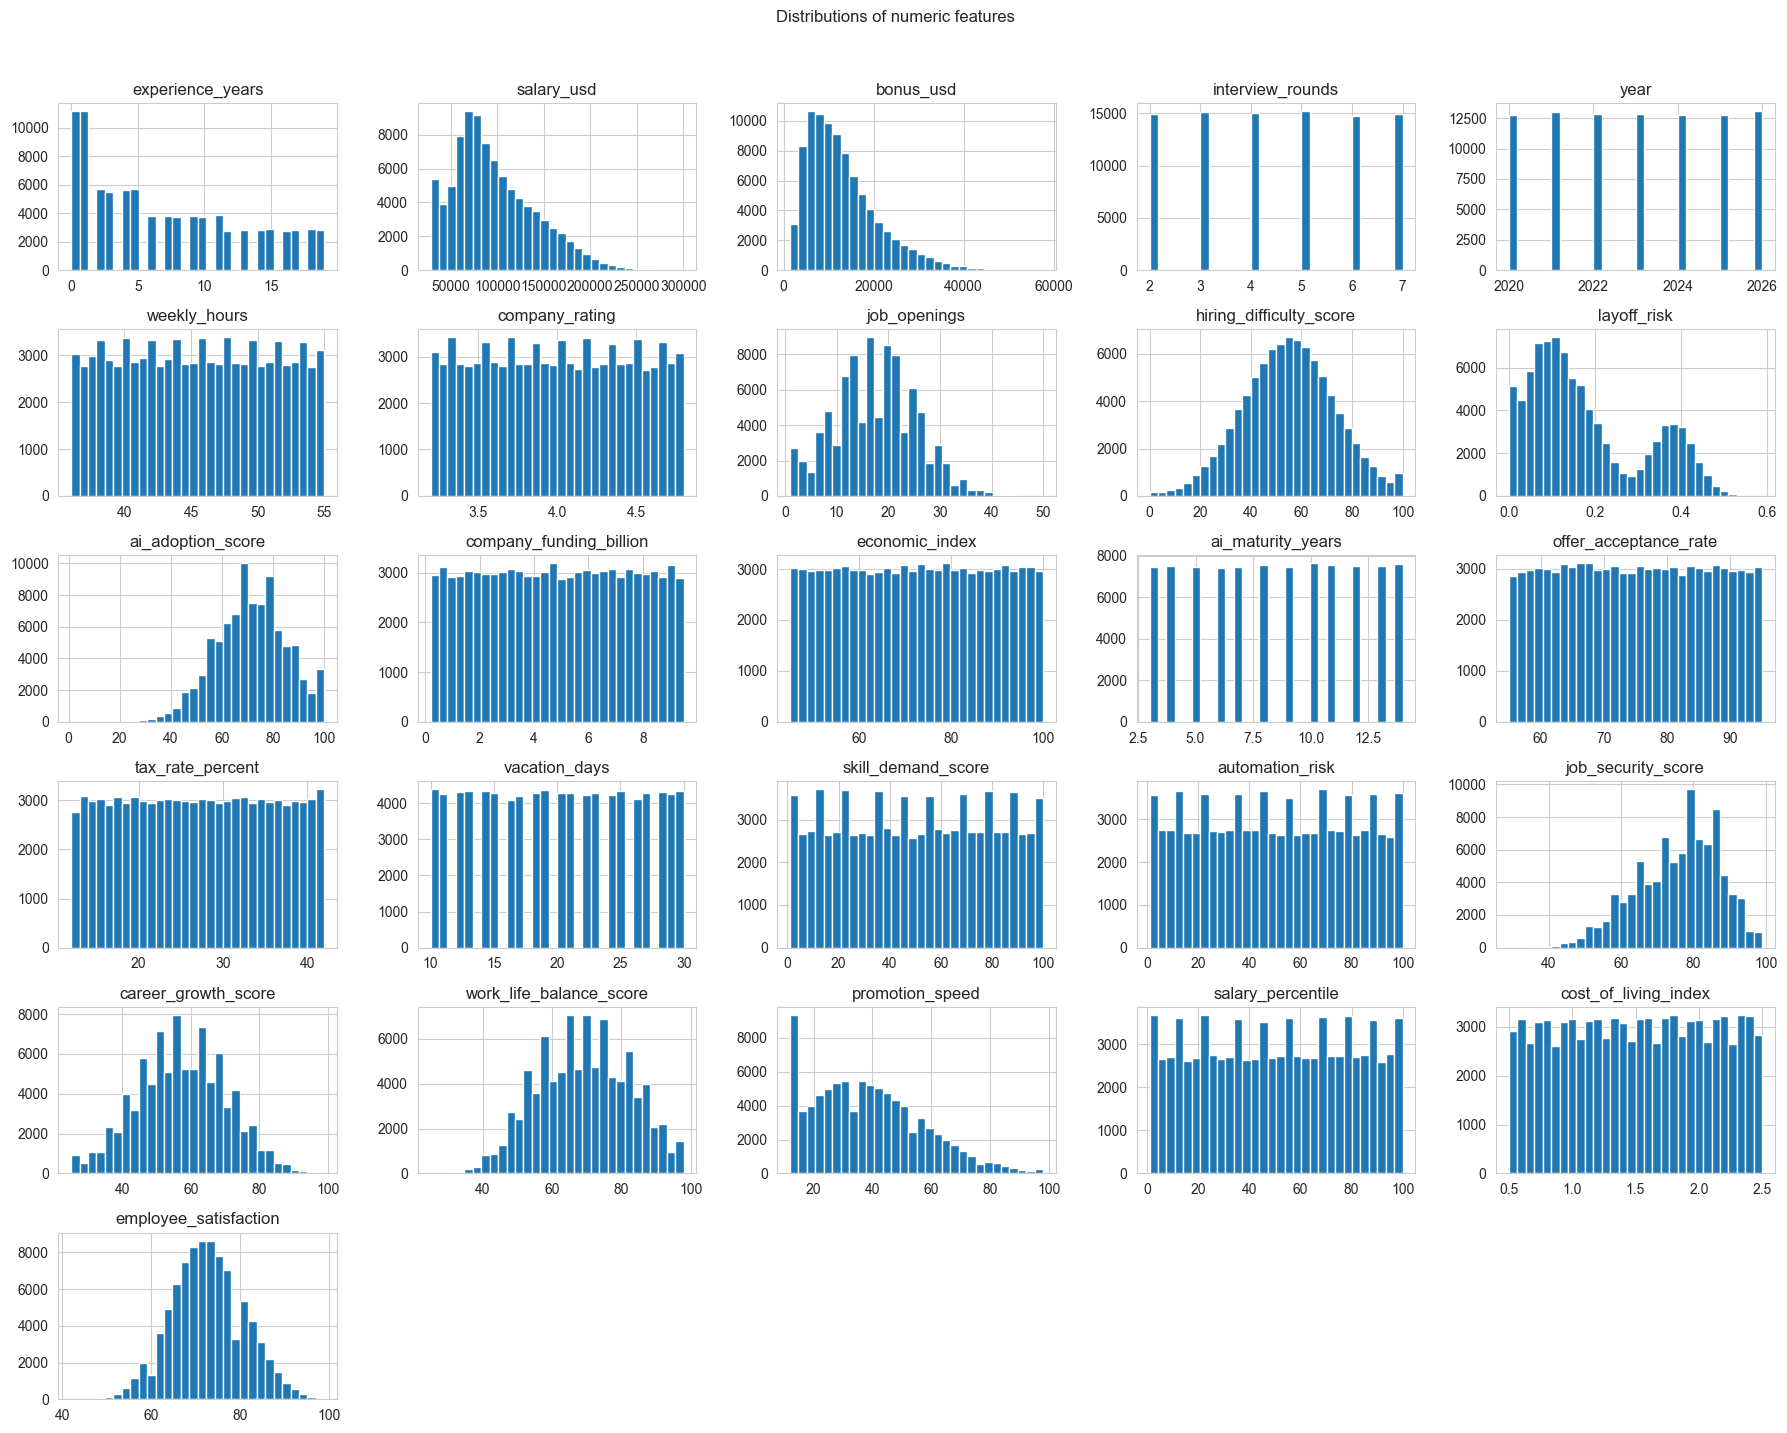

In [13]:
df[numeric_cols].hist(bins=30, figsize=(18, 14))
plt.suptitle("Distributions of numeric features", y=1.02)
plt.tight_layout()
plt.show()

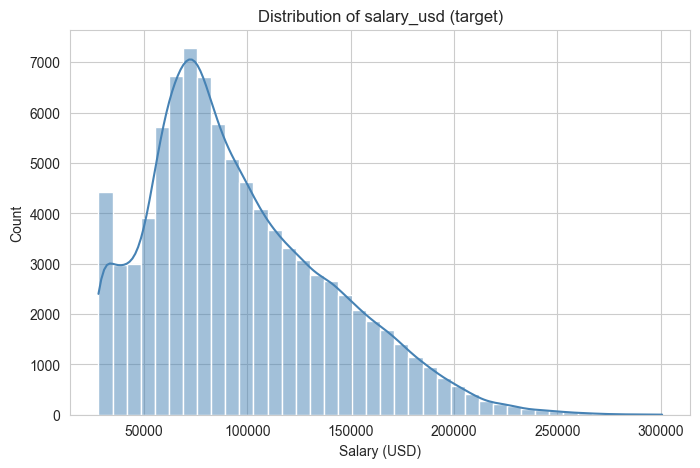

count     90000.000000
mean      96546.249222
std       43935.479553
min       28000.000000
25%       64676.750000
50%       87544.000000
75%      123906.000000
max      300622.000000
Name: salary_usd, dtype: float64
Skewness: 0.747


In [14]:
# Focused distribution on the target variable
plt.figure(figsize=(8, 5))
sns.histplot(df["salary_usd"], kde=True, bins=40, color="steelblue")
plt.title("Distribution of salary_usd (target)")
plt.xlabel("Salary (USD)")
plt.show()

print(df["salary_usd"].describe())
print("Skewness:", df["salary_usd"].skew().round(3))


## 1.6 Outlier detection
Boxplots for key continuous variables help flag potential outliers that PyCaret's `remove_outliers` option can later treat.

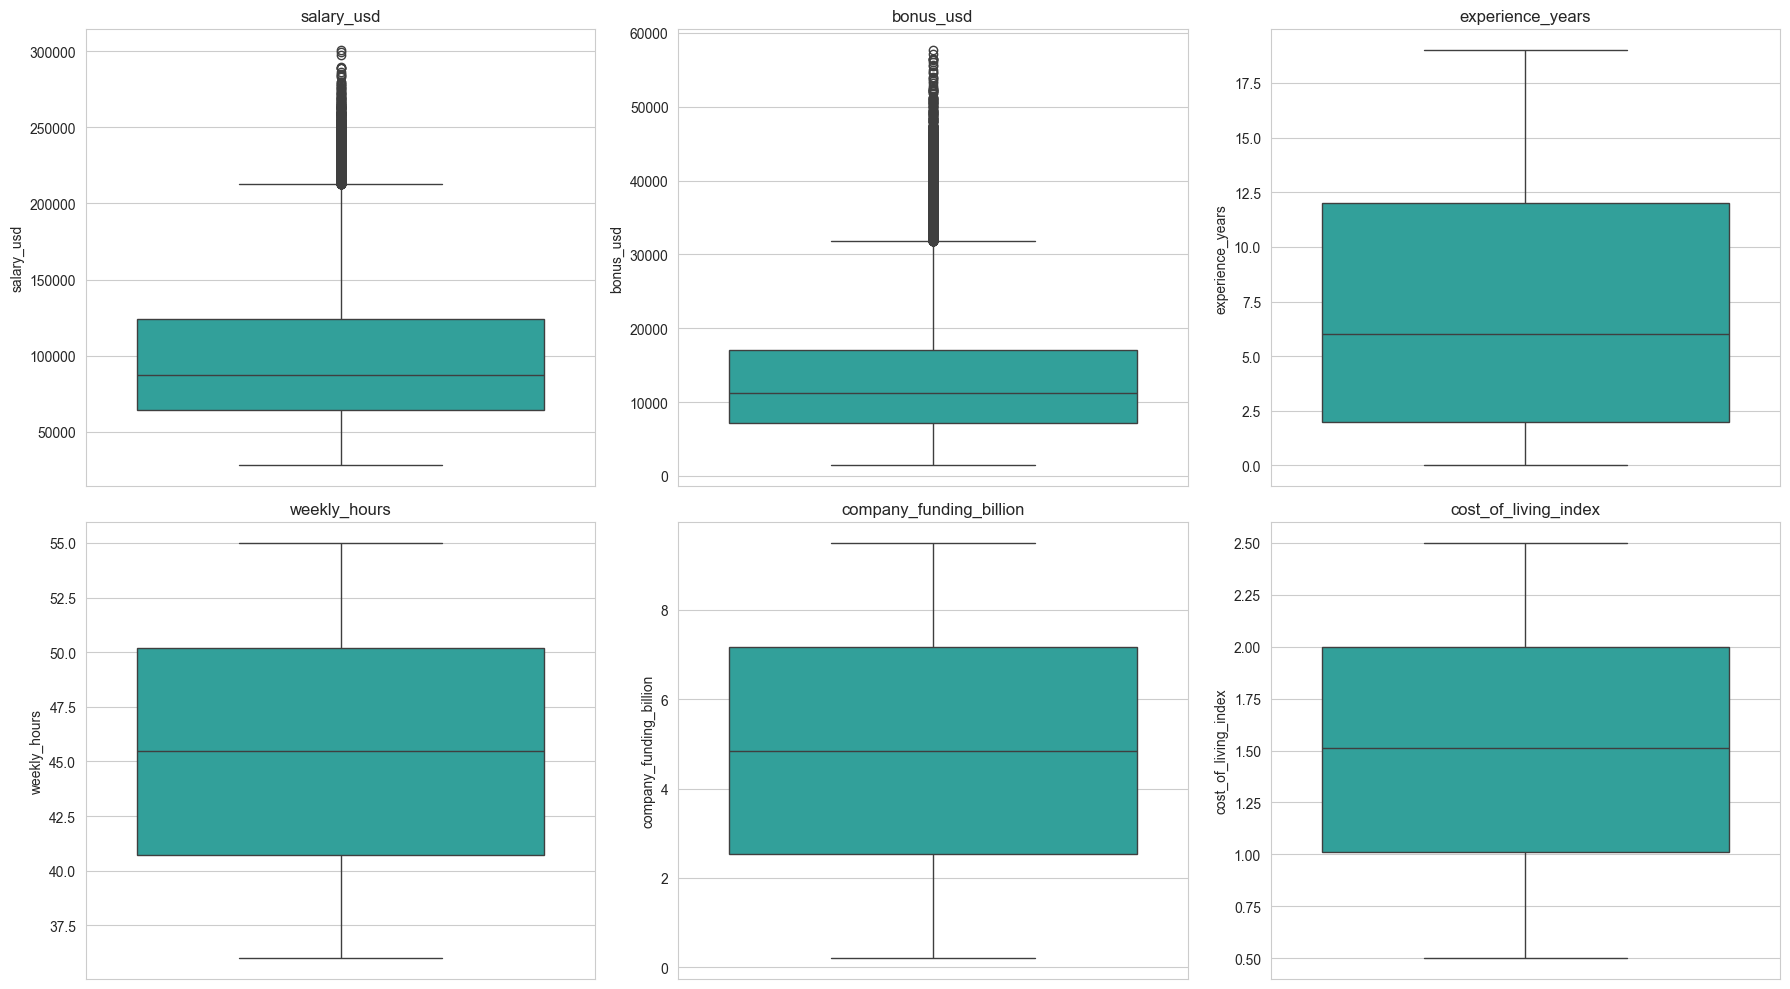

In [15]:
key_num = ["salary_usd", "bonus_usd", "experience_years", "weekly_hours",
           "company_funding_billion", "cost_of_living_index"]
key_num = [c for c in key_num if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), key_num):
    sns.boxplot(y=df[col], ax=ax, color="lightseagreen")
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 1.7 Categorical feature analysis
Frequency counts for the main categorical columns.

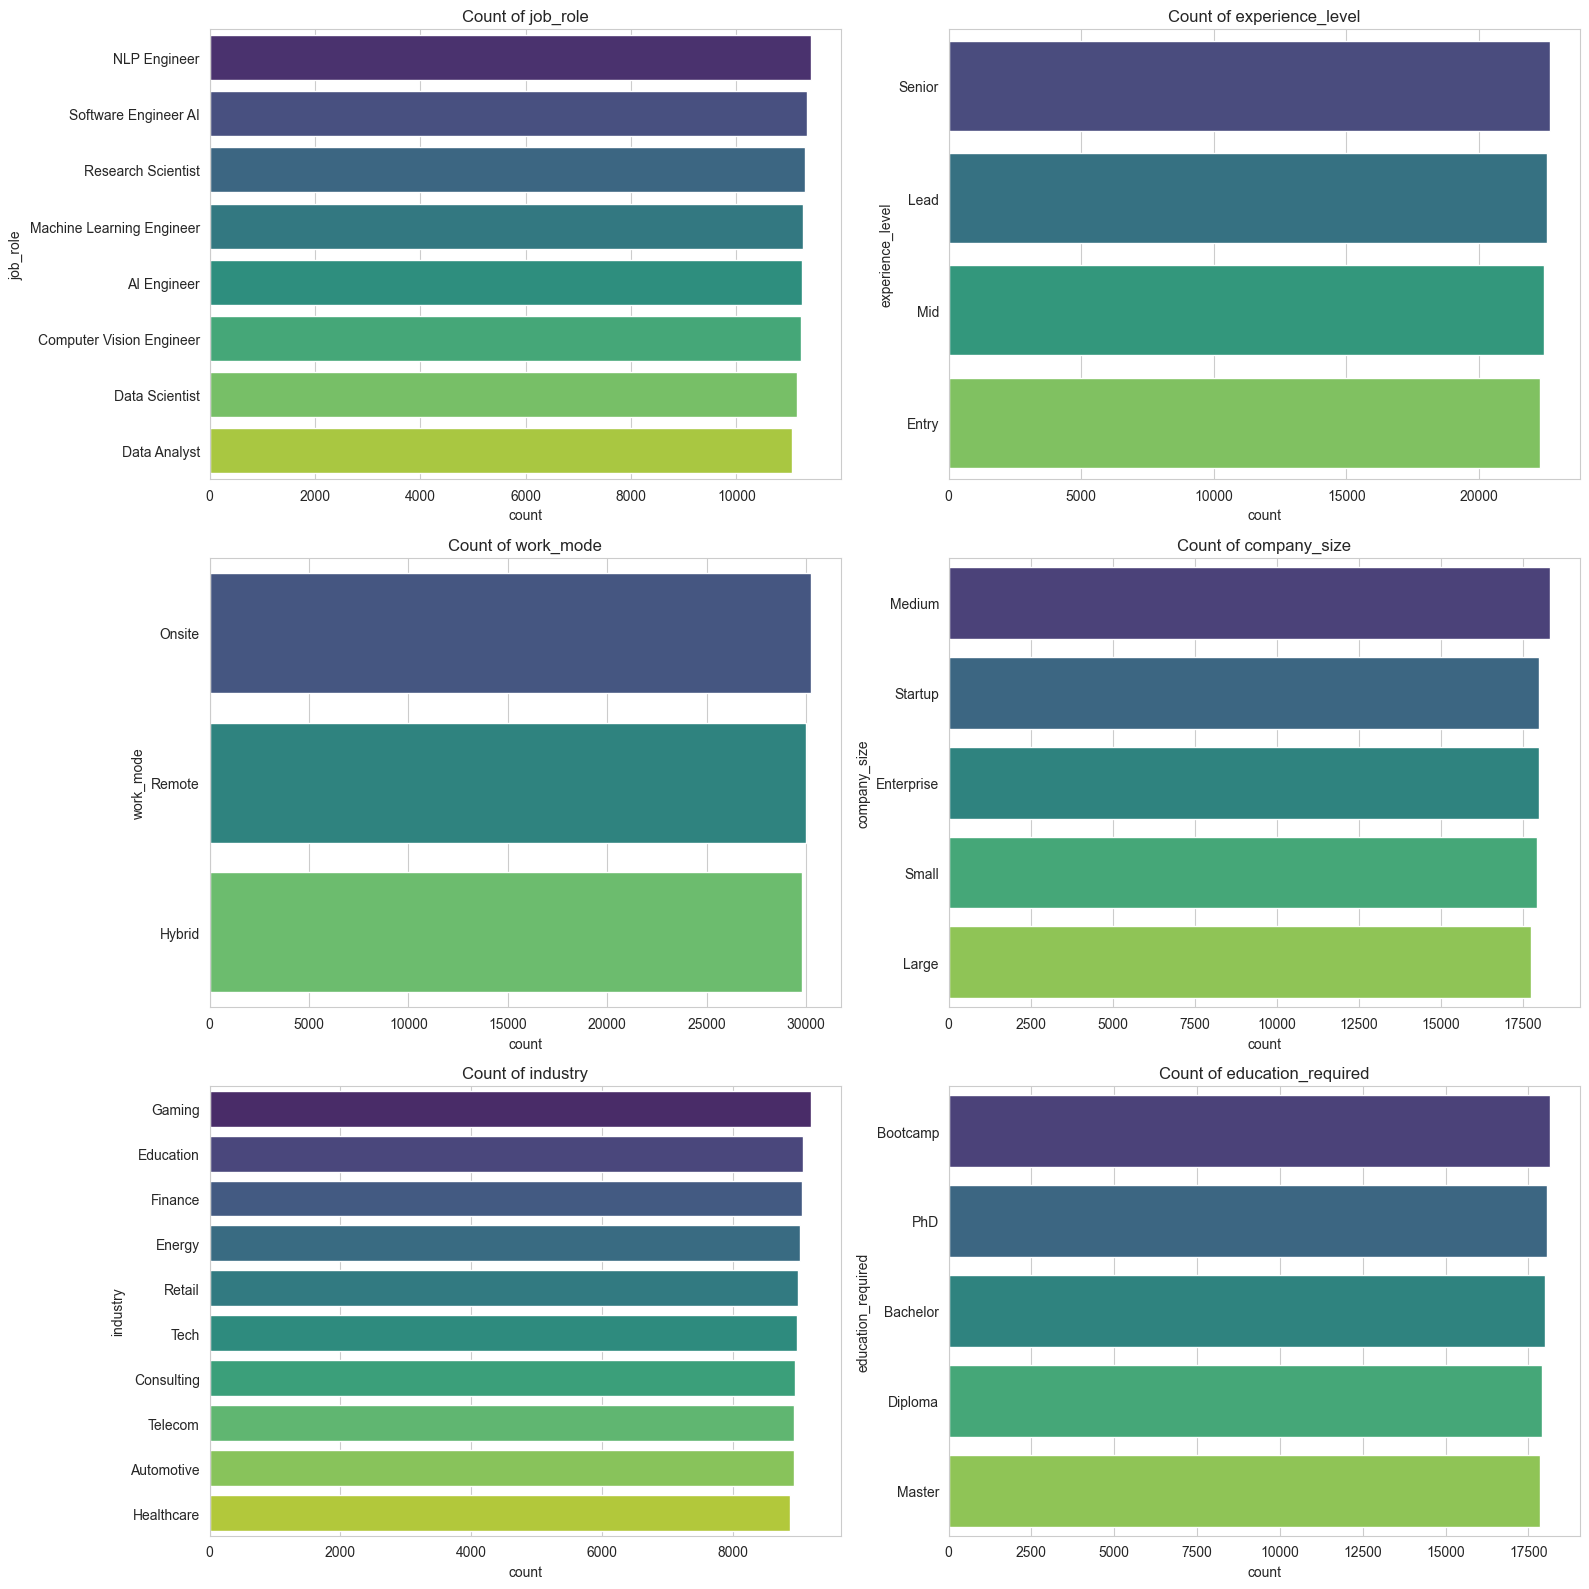

In [16]:
cat_focus = ["job_role", "experience_level", "work_mode", "company_size",
             "industry", "education_required"]
cat_focus = [c for c in cat_focus if c in df.columns]

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
for ax, col in zip(axes.flatten(), cat_focus):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax, palette="viridis")
    ax.set_title(f"Count of {col}")
plt.tight_layout()
plt.show()


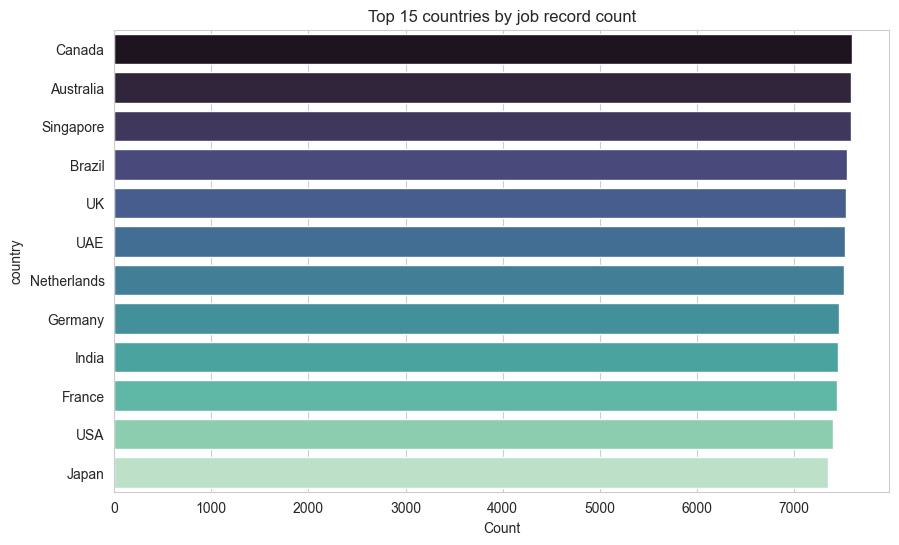

In [17]:
# Top 15 countries by number of job records
plt.figure(figsize=(10, 6))
top_countries = df["country"].value_counts().head(15)
sns.barplot(x=top_countries.values, y=top_countries.index, palette="mako")
plt.title("Top 15 countries by job record count")
plt.xlabel("Count")
plt.show()


## 1.8 Correlation analysis
Pearson correlation heatmap across numeric features to spot multicollinearity and relationships with `salary_usd`.

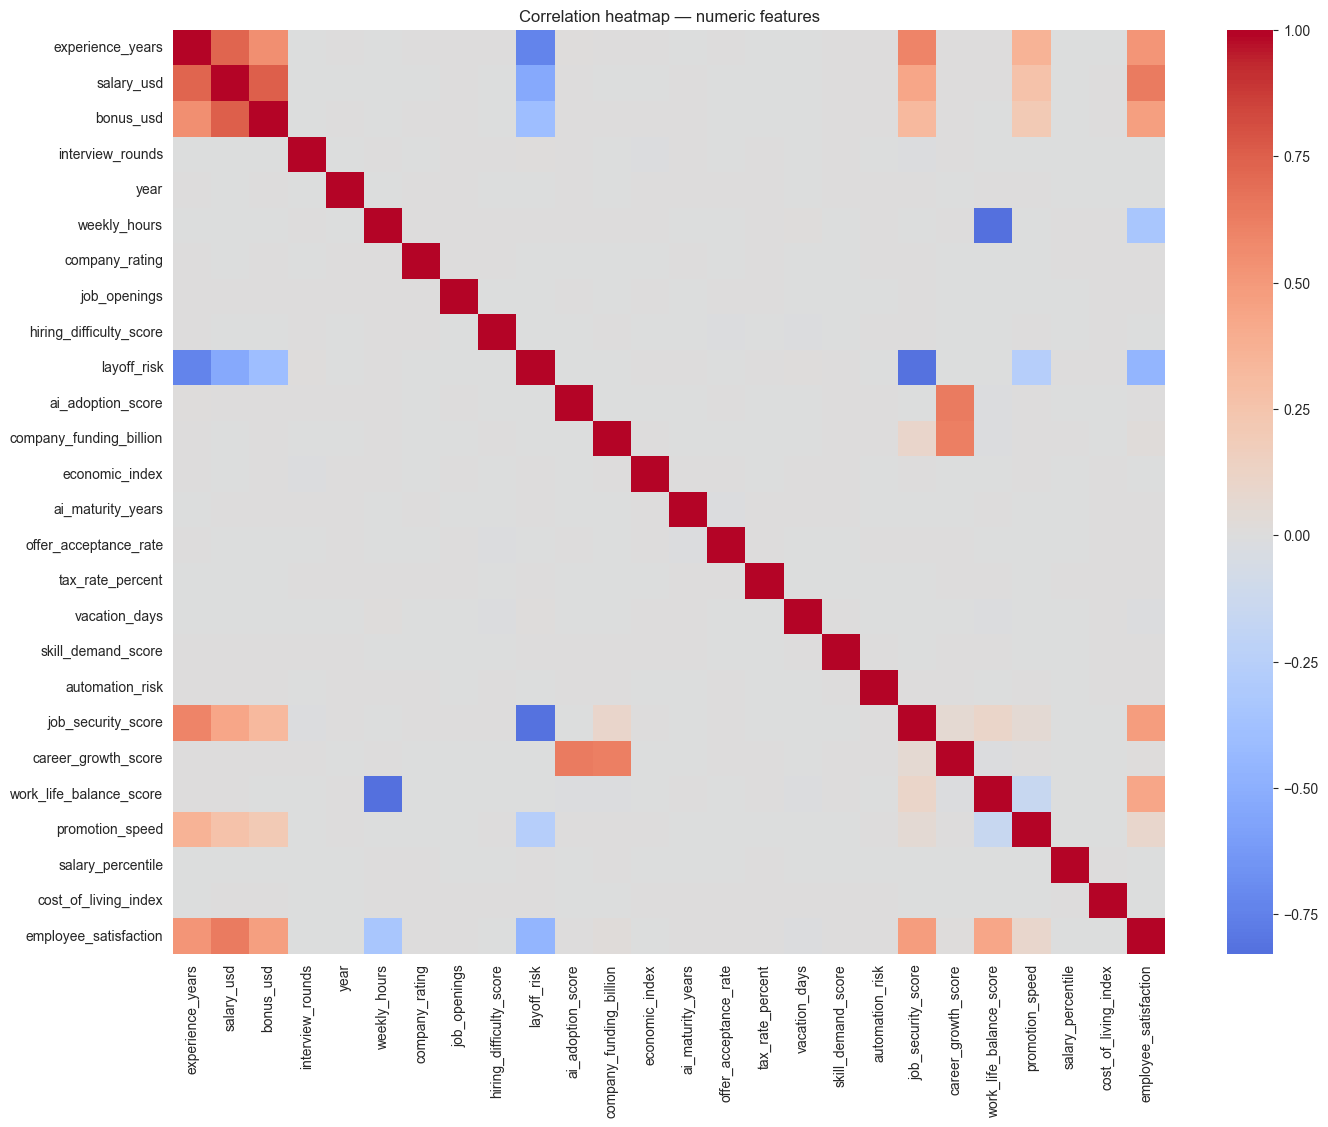

salary_usd                 1.000000
bonus_usd                  0.752046
experience_years           0.723879
employee_satisfaction      0.629030
job_security_score         0.434177
promotion_speed            0.261381
ai_adoption_score          0.006550
work_life_balance_score    0.003890
job_openings               0.003853
career_growth_score        0.003107
ai_maturity_years          0.002797
automation_risk            0.002201
cost_of_living_index       0.001462
skill_demand_score         0.001087
economic_index            -0.000094
offer_acceptance_rate     -0.000143
company_rating            -0.000347
company_funding_billion   -0.000362
hiring_difficulty_score   -0.000759
year                      -0.001309
tax_rate_percent          -0.003189
salary_percentile         -0.003327
weekly_hours              -0.004970
interview_rounds          -0.006230
vacation_days             -0.006457
layoff_risk               -0.533439
Name: salary_usd, dtype: float64

In [18]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation heatmap — numeric features")
plt.show()

# Features most correlated with salary_usd
corr["salary_usd"].sort_values(ascending=False)


In [24]:
# Drop highly_correlated feature
df.drop(columns=['bonus_usd'], inplace=True)

## 1.9 Bivariate analysis vs target (`salary_usd`)

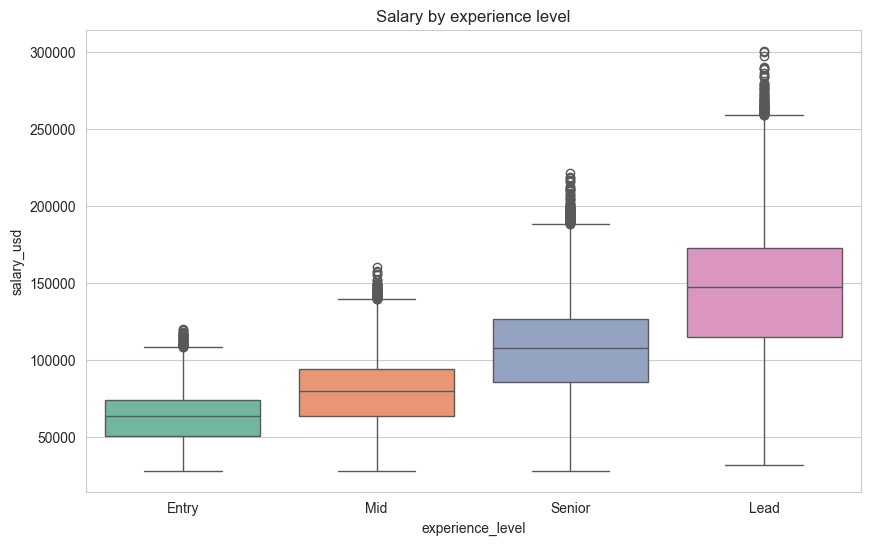

In [25]:
plt.figure(figsize=(10, 6))
order = df.groupby("experience_level")["salary_usd"].median().sort_values().index
sns.boxplot(data=df, x="experience_level", y="salary_usd", order=order, palette="Set2")
plt.title("Salary by experience level")
plt.show()

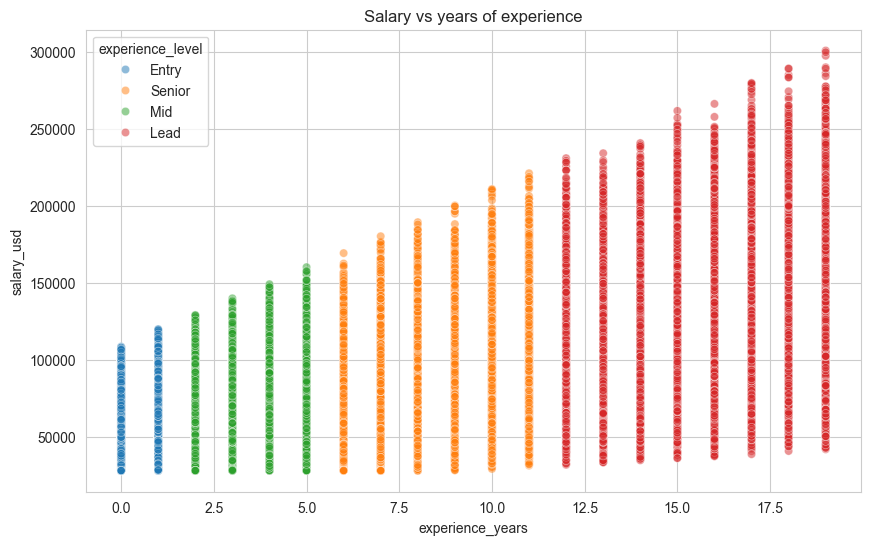

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="experience_years", y="salary_usd", hue="experience_level", alpha=0.5)
plt.title("Salary vs years of experience")
plt.show()


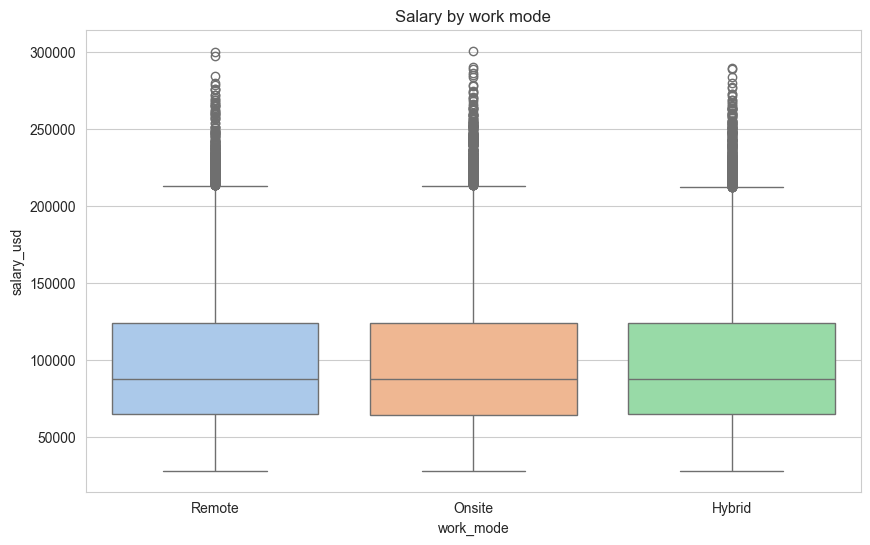

In [27]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="work_mode", y="salary_usd", palette="pastel")
plt.title("Salary by work mode")
plt.show()


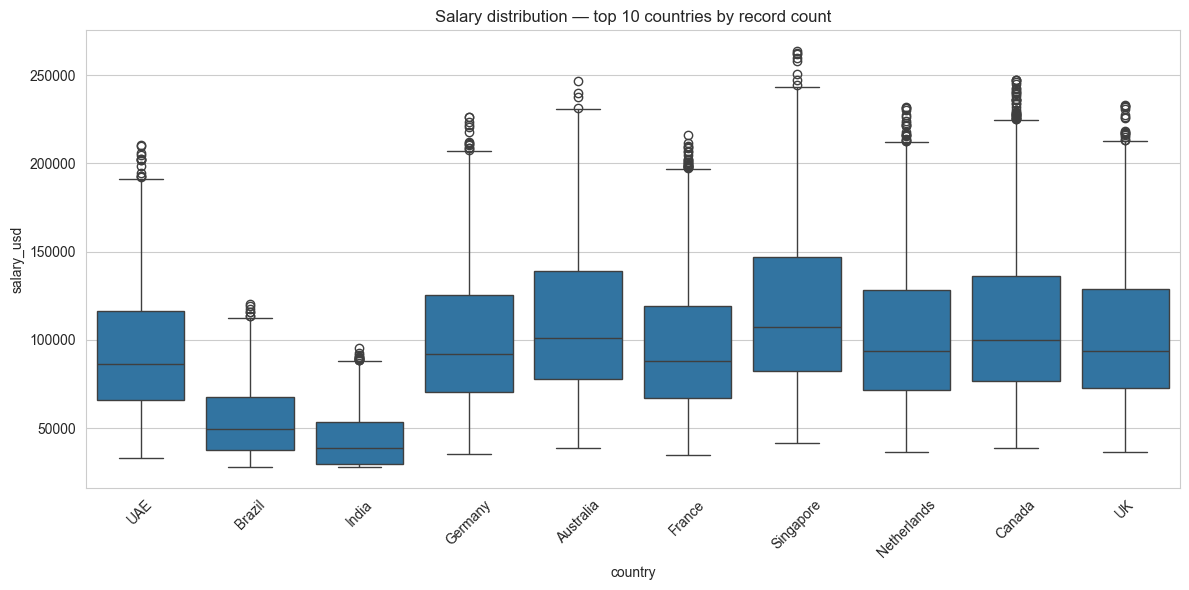

In [28]:
top10_countries = df["country"].value_counts().head(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[df["country"].isin(top10_countries)], x="country", y="salary_usd")
plt.xticks(rotation=45)
plt.title("Salary distribution — top 10 countries by record count")
plt.tight_layout()
plt.show()


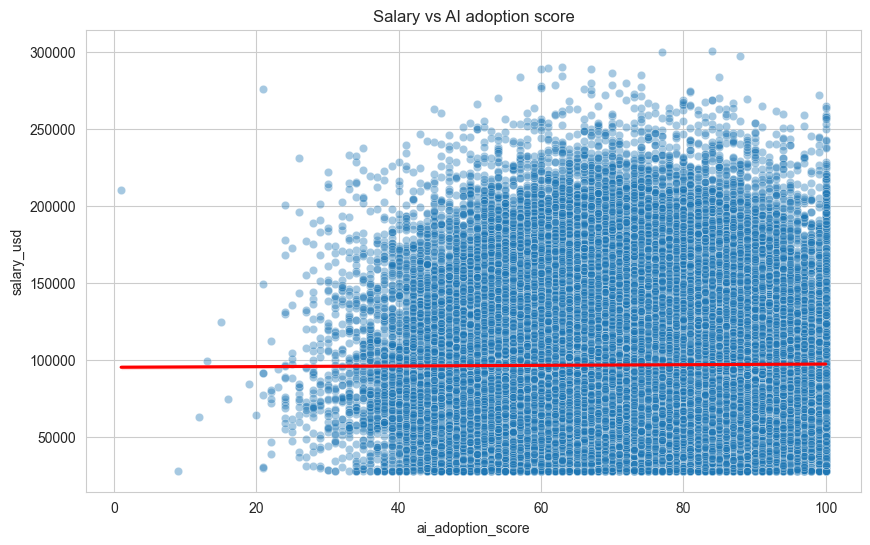

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="ai_adoption_score", y="salary_usd", alpha=0.4)
sns.regplot(data=df, x="ai_adoption_score", y="salary_usd", scatter=False, color="red")
plt.title("Salary vs AI adoption score")
plt.show()


## 1.10 EDA Summary

**Data quality**
The dataset is clean and complete: 90,000 rows x 35 columns, with **zero missing values** across every column and **zero duplicate rows**. No imputation or deduplication is required before modelling — any cleaning PyCaret's `setup()` performs (mean/mode imputation) is precautionary rather than necessary here.

**Feature composition**
26 numeric columns (25 excluding `id`) and 8 categorical columns. The categoricals are all low-to-moderate cardinality (3-12 unique values: `work_mode` has 3, `country` and `job_role`/`ai_specialization` top out around 8-12), so one-hot encoding is appropriate and won't blow up dimensionality — no need for target/frequency encoding.

**Target variable (`salary_usd`)**
Ranges from \\$28,000  to \\$300,622, mean approx \\$96,546, median approx \\$87,544, std approx \\$43,935. Skewness is **0.747** — a moderate right skew (mean pulled above the median by a tail of high earners) — which supports the choice of `transformation=True` (Yeo-Johnson) in the PyCaret `setup()` to make the target more symmetric for linear-family models.

**Correlation with salary — the key finding**
Of the 25 candidate numeric predictors, only a handful show any real linear relationship with `salary_usd`:

| Feature | Correlation |
|---|---|
| `bonus_usd` | 0.752 |
| `experience_years` | 0.724 |
| `employee_satisfaction` | 0.629 |
| `layoff_risk` | -0.533 |
| `job_security_score` | 0.434 |
| `promotion_speed` | 0.261 |

Every other numeric column — `ai_adoption_score`, `skill_demand_score`, `automation_risk`, `career_growth_score`, `company_funding_billion`, `economic_index`, `cost_of_living_index`, `hiring_difficulty_score`, `weekly_hours`, `tax_rate_percent`, `vacation_days`, `offer_acceptance_rate`, `company_rating`, `job_openings`, `ai_maturity_years`, `interview_rounds`, `year`, `salary_percentile` — sits at **|r| < 0.01**, essentially no linear signal at all. This is a strong hint that most of the "AI/HR score" columns behave like noise relative to salary, at least linearly.

`bonus_usd` has been dropped beforehand due to high correlation.

**For Task 2:** PyCaret's `feature_selection=True` will collapse 33 columns down to just a few, discarding predictors with no signal. But `corr()` only covers numeric columns, so it says nothing about whether `job_role`, `country`, `experience_level`, or `industry` matter — and the boxplots above suggest they do (visible median shifts by experience level and work mode). Worth explicitly checking that at least one categorical survives feature selection, since the correlation table alone can't rule them in or out.

**Categorical structure**
`Senior` is the most common experience level (22,680 of 90,000), `Onsite` dominates work mode (30,233), and `Canada`/`NLP Engineer`/`Computer Vision`/`Gaming` are the top categories in their respective columns — all fairly evenly spread otherwise (no single category dominates past ~30%), so there's no severe class imbalance to correct for.


---
# Task 2 — Machine Learning Pipeline with PyCaret + MLflow

We build a regression pipeline to predict `salary_usd`, track experiments in MLflow, evaluate the best model, generate predictions on unseen data, save the full pipeline, and register the final model in the MLflow Model Registry.


## 2.1 Install / import PyCaret regression module
(Run the install line once if PyCaret is not yet in your environment, then restart the kernel.)

In [30]:
# !pip install pycaret mlflow  # uncomment on first run

from pycaret.regression import (
    setup, compare_models, create_model, tune_model,
    evaluate_model, plot_model, finalize_model,
    predict_model, save_model, pull, get_config
)


## 2.2 Train / hold-out split for "unseen data"
We carve out a small, untouched sample to simulate genuinely unseen data for the final `predict_model` step in section 2.7. This sample is **not** shown to PyCaret's `setup()`.

In [31]:
df_model = df.drop(columns=["id"]) if "id" in df.columns else df.copy()

unseen_data = df_model.sample(frac=0.05, random_state=42)
train_data = df_model.drop(unseen_data.index).reset_index(drop=True)
unseen_data_no_target = unseen_data.drop(columns=["salary_usd"]).reset_index(drop=True)

print("Training data shape:", train_data.shape)
print("Unseen data shape (holdout, no target):", unseen_data_no_target.shape)


Training data shape: (85500, 33)
Unseen data shape (holdout, no target): (4500, 32)


## 2.3 Initialise the PyCaret environment (`setup`)

Preprocessing configured in `setup()`:
- `normalize=True` (`normalize_method="zscore"`) — scales numeric features.
- `transformation=True` — Yeo-Johnson power transform to reduce skewness identified in EDA (e.g. `salary_usd`, `bonus_usd`, `company_funding_billion`).
- `remove_multicollinearity=True` — drops one of each highly correlated numeric feature pair found in the EDA heatmap.
- `remove_outliers=True` — PCA-linear outlier removal on the boxplot-flagged features.
- `bin_numeric_features` — bins a couple of skewed/near-continuous score columns into intervals for the tree-based models to exploit non-linear thresholds.
- `feature_selection=True` — automatic feature importance based selection to reduce dimensionality/noise.
- `fold=10` — 10-fold cross-validation during comparison/tuning.
- `log_experiment=True`, `experiment_name=...`, `log_plots=True` — enables MLflow autologging of parameters, metrics, and diagnostic plots for every trained model.


In [32]:
import os
import re

# Reduce Git-related warnings
os.environ["GIT_PYTHON_REFRESH"] = "quiet"

# Limit CPU usage to reduce multiprocessing overhead
# when processing the large dataset
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

train_data.columns = [
    re.sub(r"[^\w]", "_", col) for col in train_data.columns
]
for col in train_data.select_dtypes(include=['object', 'category']).columns:
    train_data[col] = train_data[col].astype(str).str.strip().str.replace(r'\s+', '_', regex=True)

reg_setup = setup(
    data=train_data,
    target="salary_usd",
    session_id=123,
    train_size=0.8,
    fold=10,
    normalize=True,
    normalize_method="zscore",
    transformation=True,
    remove_multicollinearity=True,
    multicollinearity_threshold=0.9,
    remove_outliers=True,
    bin_numeric_features=["job_security_score", "ai_adoption_score"],
    feature_selection=True,
    n_features_to_select=0.6,
    log_experiment=True,
    experiment_name="global_ai_salary_prediction",
    log_plots=True,
    verbose=True,
)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014246 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2973
[LightGBM] [Info] Number of data points in the train set: 64980, number of used features: 79
[LightGBM] [Info] Start training from score 96601.681379


,Description,Value
0,Session id,123
1,Target,salary_usd
2,Target type,Regression
3,Original data shape,"(85500, 33)"
4,Transformed data shape,"(82080, 20)"
5,Transformed train set shape,"(64980, 20)"
6,Transformed test set shape,"(17100, 20)"
7,Numeric features,24
8,Categorical features,8
9,Preprocess,True


2026/08/22 18:19:24 INFO mlflow.tracking.fluent: Experiment with name 'global_ai_salary_prediction' does not exist. Creating a new experiment.


In [33]:
selected_cols = get_config("X_train_transformed").columns.tolist()
print(f"{len(selected_cols)} features kept:", selected_cols)

19 features kept: ['country_Australia', 'country_Brazil', 'country_India', 'country_Singapore', 'country_UAE', 'country_USA', 'job_role_Research_Scientist', 'job_role_Data_Analyst', 'experience_years', 'company_rating', 'hiring_difficulty_score', 'layoff_risk', 'company_funding_billion', 'economic_index', 'automation_risk', 'work_life_balance_score', 'promotion_speed', 'cost_of_living_index', 'employee_satisfaction']


In [34]:
# Summary of the transformation pipeline PyCaret built
pull()


,Description,Value
0,Session id,123
1,Target,salary_usd
2,Target type,Regression
3,Original data shape,"(85500, 33)"
4,Transformed data shape,"(82080, 20)"
5,Transformed train set shape,"(64980, 20)"
6,Transformed test set shape,"(17100, 20)"
7,Numeric features,24
8,Categorical features,8
9,Preprocess,True


## 2.4 Compare candidate models with k-fold cross-validation
`compare_models` trains every available regressor using the CV scheme from `setup()` (10-fold) and ranks them on MAE, MSE, RMSE, R2, RMSLE and MAPE.

In [35]:
warnings.filterwarnings("ignore", category=UserWarning, module="mlflow")

best_models = compare_models(sort="R2", n_select=3)
comparison_results = pull()
comparison_results

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,9175.5997,139074898.3602,11792.6965,0.9282,0.1136,0.0968,7.0910
lightgbm,Light Gradient Boosting Machine,9202.8921,139577769.2955,11814.0020,0.9280,0.1143,0.0973,3.1980
gbr,Gradient Boosting Regressor,9380.4987,145074626.8093,12044.3833,0.9251,0.1196,0.1010,6.7880
xgboost,Extreme Gradient Boosting,9354.7369,145901514.7011,12078.6749,0.9247,0.1167,0.0988,3.3050
rf,Random Forest Regressor,9432.6097,149495121.6929,12226.5392,0.9229,0.1169,0.0989,10.4450
et,Extra Trees Regressor,9481.8412,151711131.0276,12316.6781,0.9217,0.1176,0.0993,6.9570
knn,K Neighbors Regressor,11777.8361,257452829.6623,16042.8592,0.8672,0.1497,0.1228,3.7590
lar,Least Angle Regression,12608.1899,264416971.2576,16260.4715,0.8636,0.3869,0.1616,2.9630
lr,Linear Regression,12608.1899,264416971.2576,16260.4715,0.8636,0.3869,0.1616,3.9540
lasso,Lasso Regression,12607.9836,264416066.5224,16260.4440,0.8636,0.3867,0.1615,3.0140


2026/08/22 18:37:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/22 18:37:36 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/22 18:38:02 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/22 18:38:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/22 18:38:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/22 18:38:04 

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,9175.5997,1.390749e+08,11792.6965,0.9282,0.1136,0.0968,7.091
lightgbm,Light Gradient Boosting Machine,9202.8921,1.395778e+08,11814.0020,0.9280,0.1143,0.0973,3.198
gbr,Gradient Boosting Regressor,9380.4987,1.450746e+08,12044.3833,0.9251,0.1196,0.1010,6.788
xgboost,Extreme Gradient Boosting,9354.7369,1.459015e+08,12078.6749,0.9247,0.1167,0.0988,3.305
rf,Random Forest Regressor,9432.6097,1.494951e+08,12226.5392,0.9229,0.1169,0.0989,10.445
et,Extra Trees Regressor,9481.8412,1.517111e+08,12316.6781,0.9217,0.1176,0.0993,6.957
knn,K Neighbors Regressor,11777.8361,2.574528e+08,16042.8592,0.8672,0.1497,0.1228,3.759
lar,Least Angle Regression,12608.1899,2.644170e+08,16260.4715,0.8636,0.3869,0.1616,2.963
lr,Linear Regression,12608.1899,2.644170e+08,16260.4715,0.8636,0.3869,0.1616,3.954
lasso,Lasso Regression,12607.9836,2.644161e+08,16260.4440,0.8636,0.3867,0.1615,3.014


In [36]:
best_model = best_models[0] if isinstance(best_models, list) else best_models
print(best_model)

CatBoostRegressor(border_count=254, loss_function='RMSE', random_state=123, task_type='CPU', verbose=False)


## 2.5 Tune the best model
Hyperparameter tuning via randomised search, still under the same 10-fold CV, optimising R2.

In [38]:
tuned_model = tune_model(best_model, optimize="R2", n_iter=25, fold=10)
tuning_results = pull()
tuning_results

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,9396.5853,147234444.8757,12134.0201,0.9247,0.1182,0.0999
1,9564.8508,151722452.9033,12317.5668,0.9209,0.1200,0.1016
2,9364.4109,146727523.9375,12113.1137,0.9231,0.1196,0.1002
3,9555.1546,152781855.1819,12360.4957,0.9223,0.1187,0.1005
4,9319.1271,147366172.2751,12139.4470,0.9248,0.1163,0.0981
5,9476.9146,150386627.2060,12263.2225,0.9233,0.1192,0.1002
6,9458.8501,149233625.1447,12216.1215,0.9223,0.1184,0.0997
7,9242.5268,144053084.5245,12002.2117,0.9263,0.1170,0.0984
8,9315.1194,142908575.4141,11954.4375,0.9263,0.1163,0.0982


Fitting 10 folds for each of 25 candidates, totalling 250 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


2026/08/22 19:01:53 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,9396.5853,1.472344e+08,12134.0201,0.9247,0.1182,0.0999
1,9564.8508,1.517225e+08,12317.5668,0.9209,0.1200,0.1016
2,9364.4109,1.467275e+08,12113.1137,0.9231,0.1196,0.1002
3,9555.1546,1.527819e+08,12360.4957,0.9223,0.1187,0.1005
4,9319.1271,1.473662e+08,12139.4470,0.9248,0.1163,0.0981
5,9476.9146,1.503866e+08,12263.2225,0.9233,0.1192,0.1002
6,9458.8501,1.492336e+08,12216.1215,0.9223,0.1184,0.0997
7,9242.5268,1.440531e+08,12002.2117,0.9263,0.1170,0.0984
8,9315.1194,1.429086e+08,11954.4375,0.9263,0.1163,0.0982


## 2.6 Evaluate the tuned model on the test set
`plot_model` / `evaluate_model` visualise residuals, prediction error, and feature importance on PyCaret's internal test split (held out from `train_size=0.8`).

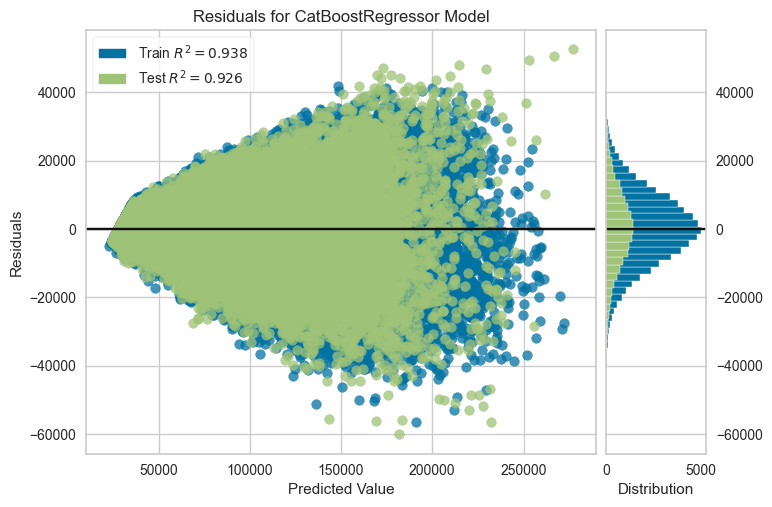

In [39]:
# Static equivalents (useful for reports / non-interactive runs)
plot_model(tuned_model, plot="residuals", plot_kwargs={"percentage": 0.2})

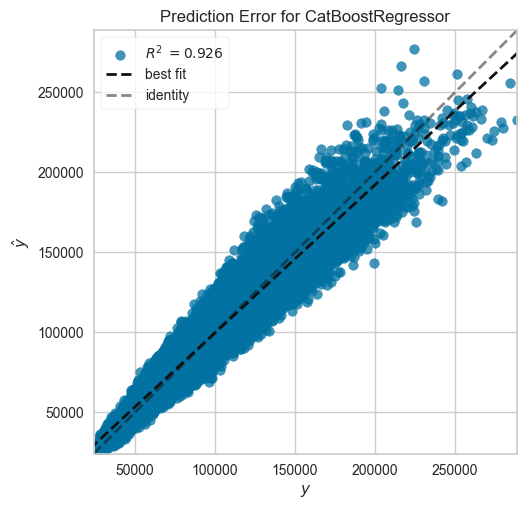

In [40]:
plot_model(tuned_model, plot="error", plot_kwargs={"percentage": 0.2})

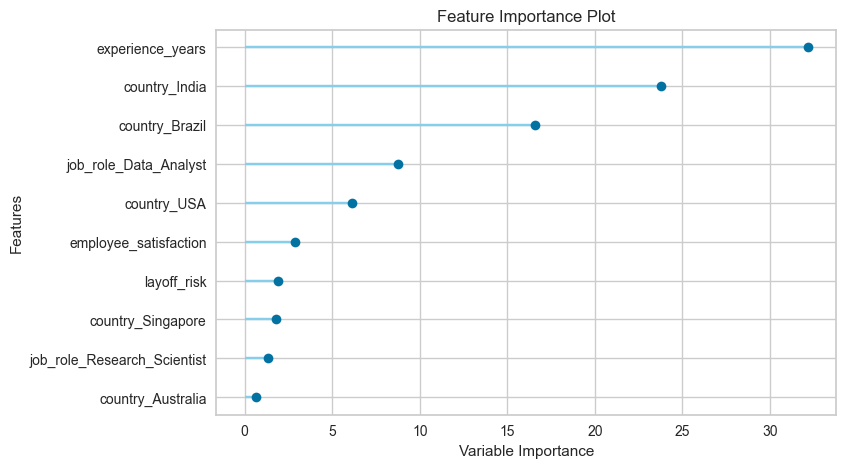

In [41]:
plot_model(tuned_model, plot="feature", plot_kwargs={"n_features_to_plot": 15})

In [42]:
# Numeric hold-out test-set metrics
predict_model(tuned_model)
test_metrics = pull()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,CatBoost Regressor,9204.7927,142076464.4710,11919.5832,0.9259,0.1144,0.0969


## 2.7 Finalise the model and predict on genuinely unseen data
`finalize_model` refits the tuned model on **100%** of the training data (train + internal test), then `predict_model` scores the untouched hold-out sample created in section 2.2.

In [47]:
from pycaret.regression import *

# Retrieve MLflow experiment logs created during PyCaret model development
training_experiment_logs = get_logs(
    experiment_name='global_ai_salary_prediction'
)

print("Number of MLflow experiment log records:", len(training_experiment_logs))
display(training_experiment_logs.tail(10))

Number of MLflow experiment log records: 22


,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.MAE,metrics.MSE,metrics.RMSE,metrics.RMSLE,...,tags.mlflow.runName,tags.mlflow.user,tags.mlflow.source.type,tags.Run Time,tags.Run ID,tags.mlflow.source.name,tags.mlflow.log-model.history,tags.mlflow.parentRunId,tags.Source,tags.URI
12,410af1875f4245fcbf99ca86631b65a0,355869025267278577,FINISHED,file:///C:/IT3385/IT3385_Env_class/notebooks/I...,2026-08-22 10:38:06.473000+00:00,2026-08-22 10:38:06.850000+00:00,12608.1899,2.644170e+08,16260.4715,0.3869,...,Linear Regression,crypt,LOCAL,40.03,410af1875f4245fcbf99ca86631b65a0,C:\IT3385\IT3385_Env_class\env\lib\site-packag...,"[{""run_id"": ""410af1875f4245fcbf99ca86631b65a0""...",89be6c78567e41ecad0b423a3ea3615e,compare_models,2171a355
13,40fa94bc0e1f404b93bdff003d664d79,355869025267278577,FINISHED,file:///C:/IT3385/IT3385_Env_class/notebooks/I...,2026-08-22 10:38:05.780000+00:00,2026-08-22 10:38:06.178000+00:00,12608.1899,2.644170e+08,16260.4715,0.3869,...,Least Angle Regression,crypt,LOCAL,30.01,40fa94bc0e1f404b93bdff003d664d79,C:\IT3385\IT3385_Env_class\env\lib\site-packag...,"[{""run_id"": ""40fa94bc0e1f404b93bdff003d664d79""...",89be6c78567e41ecad0b423a3ea3615e,compare_models,baa8b1fe
14,572020f03c0c47a1995bb7f7ffcb6603,355869025267278577,FINISHED,file:///C:/IT3385/IT3385_Env_class/notebooks/I...,2026-08-22 10:38:05.026000+00:00,2026-08-22 10:38:05.486000+00:00,11777.8361,2.574528e+08,16042.8592,0.1497,...,K Neighbors Regressor,crypt,LOCAL,37.96,572020f03c0c47a1995bb7f7ffcb6603,C:\IT3385\IT3385_Env_class\env\lib\site-packag...,"[{""run_id"": ""572020f03c0c47a1995bb7f7ffcb6603""...",89be6c78567e41ecad0b423a3ea3615e,compare_models,3276229b
15,839e562f3b894f30b9023c96084a87b7,355869025267278577,FINISHED,file:///C:/IT3385/IT3385_Env_class/notebooks/I...,2026-08-22 10:38:04.340000+00:00,2026-08-22 10:38:04.736000+00:00,9481.8412,1.517111e+08,12316.6781,0.1176,...,Extra Trees Regressor,crypt,LOCAL,70.03,839e562f3b894f30b9023c96084a87b7,C:\IT3385\IT3385_Env_class\env\lib\site-packag...,"[{""run_id"": ""839e562f3b894f30b9023c96084a87b7""...",89be6c78567e41ecad0b423a3ea3615e,compare_models,1fccef07
16,5946a288238b4283837e028b7b258e31,355869025267278577,FINISHED,file:///C:/IT3385/IT3385_Env_class/notebooks/I...,2026-08-22 10:38:03.631000+00:00,2026-08-22 10:38:04.039000+00:00,9432.6097,1.494951e+08,12226.5392,0.1169,...,Random Forest Regressor,crypt,LOCAL,104.87,5946a288238b4283837e028b7b258e31,C:\IT3385\IT3385_Env_class\env\lib\site-packag...,"[{""run_id"": ""5946a288238b4283837e028b7b258e31""...",89be6c78567e41ecad0b423a3ea3615e,compare_models,18a86212
17,222802c17f494352891d8caa641cf473,355869025267278577,FINISHED,file:///C:/IT3385/IT3385_Env_class/notebooks/I...,2026-08-22 10:38:02.867000+00:00,2026-08-22 10:38:03.335000+00:00,9354.7369,1.459015e+08,12078.6749,0.1167,...,Extreme Gradient Boosting,crypt,LOCAL,33.44,222802c17f494352891d8caa641cf473,C:\IT3385\IT3385_Env_class\env\lib\site-packag...,"[{""run_id"": ""222802c17f494352891d8caa641cf473""...",89be6c78567e41ecad0b423a3ea3615e,compare_models,2e4ade50
18,de4eec51c81a4dc4bf0e73632906f837,355869025267278577,FINISHED,file:///C:/IT3385/IT3385_Env_class/notebooks/I...,2026-08-22 10:37:56.520000+00:00,2026-08-22 10:38:02.582000+00:00,9380.4987,1.450746e+08,12044.3833,0.1196,...,Gradient Boosting Regressor,crypt,LOCAL,68.26,de4eec51c81a4dc4bf0e73632906f837,C:\IT3385\IT3385_Env_class\env\lib\site-packag...,"[{""run_id"": ""de4eec51c81a4dc4bf0e73632906f837""...",89be6c78567e41ecad0b423a3ea3615e,compare_models,938a5ba9
19,a82514664d4244b28fd8f44308300290,355869025267278577,FINISHED,file:///C:/IT3385/IT3385_Env_class/notebooks/I...,2026-08-22 10:37:30.080000+00:00,2026-08-22 10:37:36.573000+00:00,9202.8921,1.395778e+08,11814.0020,0.1143,...,Light Gradient Boosting Machine,crypt,LOCAL,32.37,a82514664d4244b28fd8f44308300290,C:\IT3385\IT3385_Env_class\env\lib\site-packag...,"[{""run_id"": ""a82514664d4244b28fd8f44308300290""...",89be6c78567e41ecad0b423a3ea3615e,compare_mo

In [48]:
final_model = finalize_model(tuned_model)
print(final_model)

2026/08/22 21:39:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['experience_years',
                                             'interview_rounds', 'year',
                                             'weekly_hours', 'company_rating',
                                             'job_openings',
                                             'hiring_difficulty_score',
                                             'layoff_risk', 'ai_adoption_score',
                                             'company_funding_billion',
                                             'economic_index',
                                             'ai_maturity_years',
                                             'offer_acceptance_rate',
                                             'tax_rate_percent...
                 TransformerWrapper(transformer=PowerTransformer(standardize=False))),
                ('normalize', TransformerWrapper(transformer=Standar

In [49]:
unseen_predictions = predict_model(final_model, data=unseen_data_no_target)
unseen_predictions.head(10)

,country,job_role,ai_specialization,experience_level,experience_years,education_required,industry,company_size,interview_rounds,year,...,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction,prediction_label
0,Germany,Research Scientist,LLM,Mid,4,Diploma,Consulting,Startup,3,2025,...,29,43,57,76,67,48,46,2.19,65,82550.689481
1,Netherlands,Machine Learning Engineer,NLP,Senior,8,PhD,Energy,Small,7,2025,...,74,56,73,26,56,26,21,2.00,76,110089.596754
2,Brazil,Machine Learning Engineer,Reinforcement Learning,Mid,4,Diploma,Energy,Small,2,2022,...,85,79,71,62,95,47,49,1.09,83,45506.015167
3,France,Machine Learning Engineer,Forecasting,Senior,7,Master,Education,Medium,2,2026,...,46,28,84,56,57,19,26,0.98,63,98928.318018
4,Brazil,Research Scientist,Computer Vision,Mid,2,Bachelor,Telecom,Enterprise,2,2026,...,52,2,81,73,61,29,65,1.07,71,40909.545829
5,Netherlands,Computer Vision Engineer,LLM,Entry,1,Bootcamp,Tech,Medium,3,2026,...,41,40,68,66,65,22,16,1.68,76,69626.606080
6,Brazil,AI Engineer,Analytics,Mid,5,Master,Retail,Startup,4,2025,...,45,97,75,68,49,53,40,1.81,68,49451.758901
7,Brazil,NLP Engineer,Analytics,Lead,15,Bootcamp,Automotive,Medium,5,2022,...,55,85,81,78,56,84,22,1.98,64,76981.433529
8,Netherlands,Data Analyst,Analytics,Senior,10,Bachelor,Automotive,Large,5,2026,...,21,42,85,63,83,48,17,0.50,75,117178.664068
9,Netherlands,Data Scientist,Analytics,Senior,7,PhD,Finance,Enterprise,2,2025,...,9,61,73,49,87,12,56,1.07,70,97827.159335


In [50]:
# Compare predictions against the true salary we withheld earlier
comparison = unseen_predictions[["prediction_label"]].copy()
comparison["actual_salary_usd"] = unseen_data["salary_usd"].values
comparison["abs_error"] = (comparison["prediction_label"] - comparison["actual_salary_usd"]).abs()
comparison.head(10)

,prediction_label,actual_salary_usd,abs_error
0,82550.689481,101570,19019.310519
1,110089.596754,105712,4377.596754
2,45506.015167,48774,3267.984833
3,98928.318018,88187,10741.318018
4,40909.545829,39660,1249.545829
5,69626.606080,82533,12906.393920
6,49451.758901,46455,2996.758901
7,76981.433529,71006,5975.433529
8,117178.664068,97298,19880.664068
9,97827.159335,105023,7195.840665


## 2.8 Save the entire pipeline
`save_model` persists the full PyCaret pipeline (preprocessing + final estimator) as a single `.pkl` file, so it can be reloaded later with `load_model()` for inference without re-running `setup()`.

In [53]:
PIPELINE_NAME = str(FINAL_MODEL_PATH)

save_model(final_model, PIPELINE_NAME)
print(f"Pipeline saved as {PIPELINE_NAME}.pkl")

Transformation Pipeline and Model Successfully Saved
Pipeline saved as C:\IT3385\IT3385_Env_class\notebooks\IT3385_Team5_Assignment\src\team5_app\Long Chen\salary_predictor_app\employee_salary_final_model.pkl


## 2.9 Register the final model with MLflow

PyCaret's `log_experiment=True` already logged every run (params, CV metrics, and plots) to the local MLflow tracking store under the experiment `global_ai_salary_prediction`. Here we locate the run for our finalised model and promote it to the **MLflow Model Registry**.


In [61]:
import mlflow
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri(
    "file:C:/IT3385/IT3385_Env_class/notebooks/IT3385_Team5_Assignment/notebooks/mlruns"
)

client = MlflowClient()
experiment = client.get_experiment_by_name("global_ai_salary_prediction")
print("Experiment ID:", experiment.experiment_id)

runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="metrics.R2 > 0",
    order_by=["metrics.R2 DESC"],
    max_results=1,
)

if not runs:
    raise ValueError("No run with an R2 metric found — check the experiment name/tracking URI.")

best_run = runs[0]
print("Best run ID:", best_run.info.run_id)
best_run.data.metrics


Experiment ID: 355869025267278577
Best run ID: 772b97a2b6b74984903454accf6fb92b


{'MAE': 9175.5997,
 'MAPE': 0.0968,
 'MSE': 139074898.3602,
 'R2': 0.9282,
 'RMSE': 11792.6965,
 'RMSLE': 0.1136,
 'TT': 7.091}

In [62]:
MODEL_NAME = "global_ai_salary_prediction"

model_uri = f"runs:/{best_run.info.run_id}/model"

registered_model = mlflow.register_model(
    model_uri=model_uri,
    name=MODEL_NAME,
)

print(f"Registered '{MODEL_NAME}' as version {registered_model.version}")


Registered 'global_ai_salary_prediction' as version 1


Successfully registered model 'global_ai_salary_prediction'.
Created version '1' of model 'global_ai_salary_prediction'.


In [63]:
# Optional: promote the newly registered version to the "Production" alias/stage
client.transition_model_version_stage(
    name=MODEL_NAME,
    version=registered_model.version,
    stage="Production",
    archive_existing_versions=True,
)

print(f"{MODEL_NAME} v{registered_model.version} moved to Production stage.")


global_ai_salary_prediction v1 moved to Production stage.


## 2.10 View results in the MLflow UI
From a terminal in the same directory as this notebook (so it can find the `mlruns` folder), run:

```
mlflow ui
```

Then open `http://127.0.0.1:5000` to browse:
- The `global_ai_salary_prediction` experiment: every candidate model from `compare_models`, its CV metrics per fold, and diagnostic plots logged by `log_plots=True`.
- The **Models** tab: the registered `GlobalAISalaryRegressor` with its version history and stage (Production).


---
## Summary / Documentation

1. **EDA (Task 1):** inspected structure, missingness, duplicates, distributions, outliers, categorical frequencies and correlations, focusing on relationships with `salary_usd`.
2. **PyCaret setup:** configured scaling (z-score normalisation), Yeo-Johnson transformation for skew, multicollinearity removal, outlier removal, binning of two score features, and automatic feature selection — building a reusable transformation pipeline.
3. **Model comparison:** `compare_models` ran every regressor under 10-fold CV and ranked by R2 (also reporting MAE, MSE, RMSE, RMSLE, MAPE).
4. **Tuning:** the top model was hyperparameter-tuned with `tune_model`, still under 10-fold CV.
5. **Evaluation:** residual, error and feature-importance plots plus hold-out test metrics via `evaluate_model` / `plot_model` / `predict_model`.
6. **Unseen-data prediction:** the finalised model (refit on 100% of training data) predicted salaries on a 5% sample withheld before `setup()` and never seen during training/tuning.
7. **Pipeline persistence:** the full pipeline (preprocessing + model) was saved with `save_model` to `global_ai_salary_pipeline.pkl`.
8. **MLflow logging & registration:** `log_experiment=True` auto-logged every trained model's parameters, CV metrics and plots; the finalised run was then registered in the MLflow Model Registry as `GlobalAISalaryRegressor` and promoted to the Production stage.
